In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
from mab.algorithms import exp3_plus_plus, ucb, exp3
from mab.environment.stationary.bernoulli import Bernoulli
from mab.environment.stationary.utils import Agent
from mab.environment.experiment import Experiment
from mab.environment.plots import plot_regret

In [33]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [34]:
EXP3PlusPlus = exp3_plus_plus.EXP3PlusPlus
class Exp3PlusPlus(EXP3PlusPlus):
    def __init__(self, n_arms, **kwargs):
        super().__init__(n_arms, **kwargs)

    def cal_xi(self):
        gaps = self.estimate_gaps() + 1e-10 # To avoid division by zero
        temp = (np.log(self.iters*(gaps**2))) / (32*self.iters*(gaps**2))
        return temp

In [35]:
# Define the experiment parameters
n_arms = 2
time_horizon = int(1e6)
num_simulations = 5
delta = 0.1

bernoulli_probs = [0.5, 0.5+delta]  # True probabilities for each arm
env = Bernoulli(mean_rewards=bernoulli_probs, seed=42)

In [36]:
# Initialize the algorithms
ucb_agent = Agent(ucb.UCB(n_arms=n_arms))
exp3_agent = Agent(exp3.EXP3(n_arms=n_arms, seed=42))
exp3_plus_plus_agent = Agent(exp3_plus_plus.EXP3PlusPlus(n_arms=n_arms, seed=42))

In [37]:
algorithms = [ucb_agent, exp3_agent, exp3_plus_plus_agent]

# Run the experiment
experiment = Experiment(env, algorithms, time_horizon, num_simulations)
experiment.run()

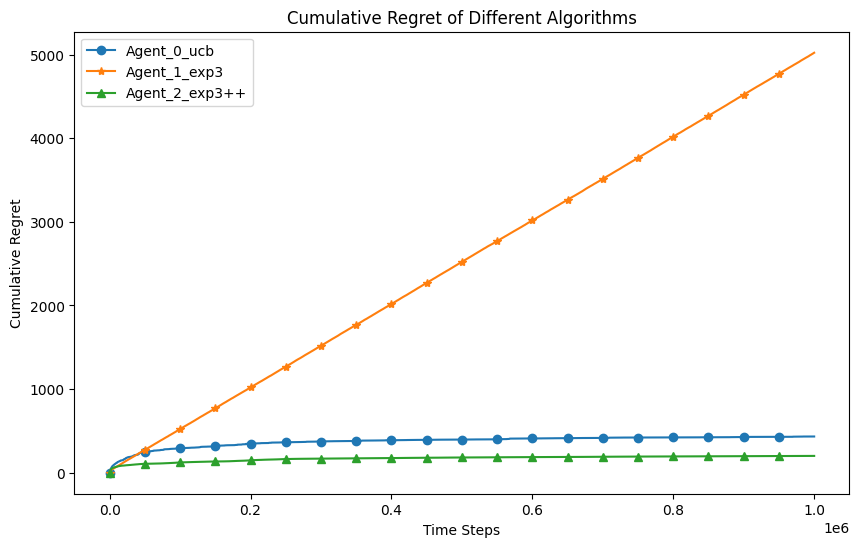

<Figure size 640x480 with 0 Axes>

In [38]:
regret_dict = experiment.compute_average_regret()
regret_plot = plot_regret(regret_dict)

In [ ]:
# Debugging exp3 algorithm
exp3_agent = Agent(exp3.EXP3(n_arms=n_arms, seed=42))
algorithms = [exp3_agent]

# Run the experiment
experiment = Experiment(env, algorithms, time_horizon, num_simulations)
experiment.run()